In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

quality_df = pd.read_csv("../data/image_quality_metrics.csv")
infodump_df = pd.read_csv("../data/raw_subject_data.csv")

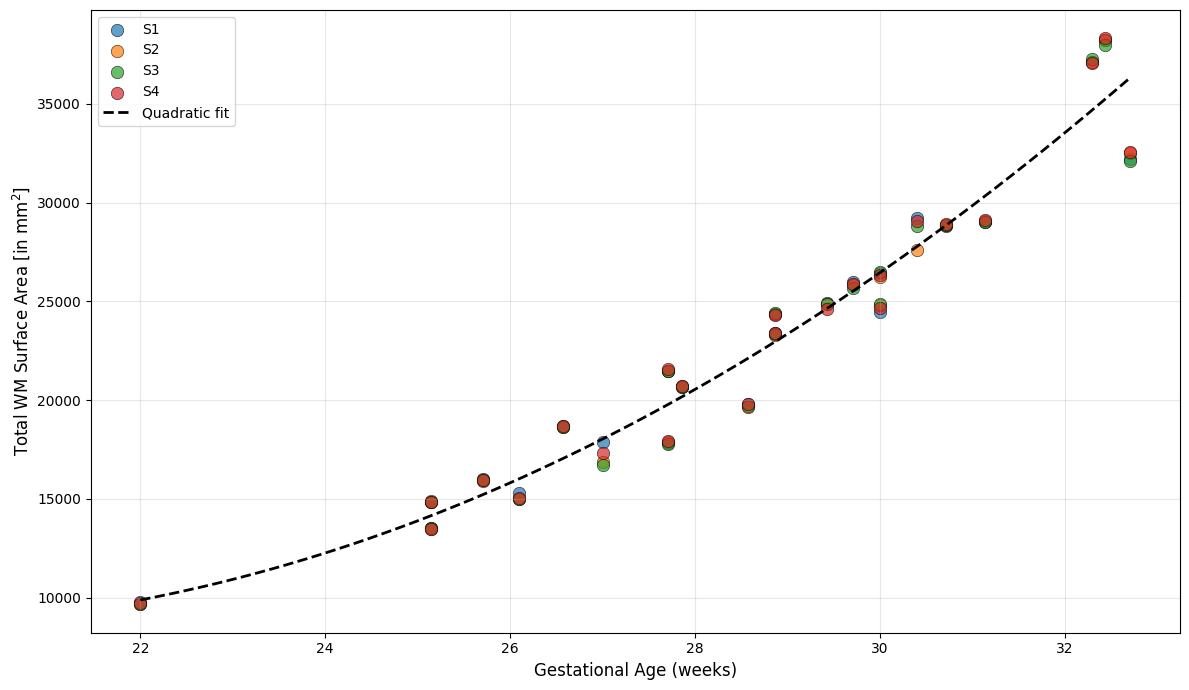

In [3]:
fig, ax = plt.subplots(figsize=(12, 7))


split_colors = {'S1': '#1f77b4', 'S2': '#ff7f0e', 'S3': '#2ca02c', 'S4': '#d62728'}

for split in ['S1', 'S2', 'S3', 'S4']:
    split_data = quality_df[quality_df['split'] == split]
    ax.scatter(split_data['GA'], split_data['wm_surface_area'],
              label=split, color=split_colors[split], s=80, alpha=0.7, edgecolors='black', linewidth=0.5)

ga_vals = quality_df['GA'].values
surface_vals = quality_df['wm_surface_area'].values
valid_idx = ~(np.isnan(ga_vals) | np.isnan(surface_vals))
ga_clean = ga_vals[valid_idx]
surface_clean = surface_vals[valid_idx]

coeffs = np.polyfit(ga_clean, surface_clean, 2)
poly = np.poly1d(coeffs)
ga_range = np.linspace(ga_clean.min(), ga_clean.max(), 100)
ax.plot(ga_range, poly(ga_range), 'k--', linewidth=2, label='Quadratic fit')

ax.set_xlabel('Gestational Age (weeks)', fontsize=12)
ax.set_ylabel('Total WM Surface Area [in mm$^2$]', fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

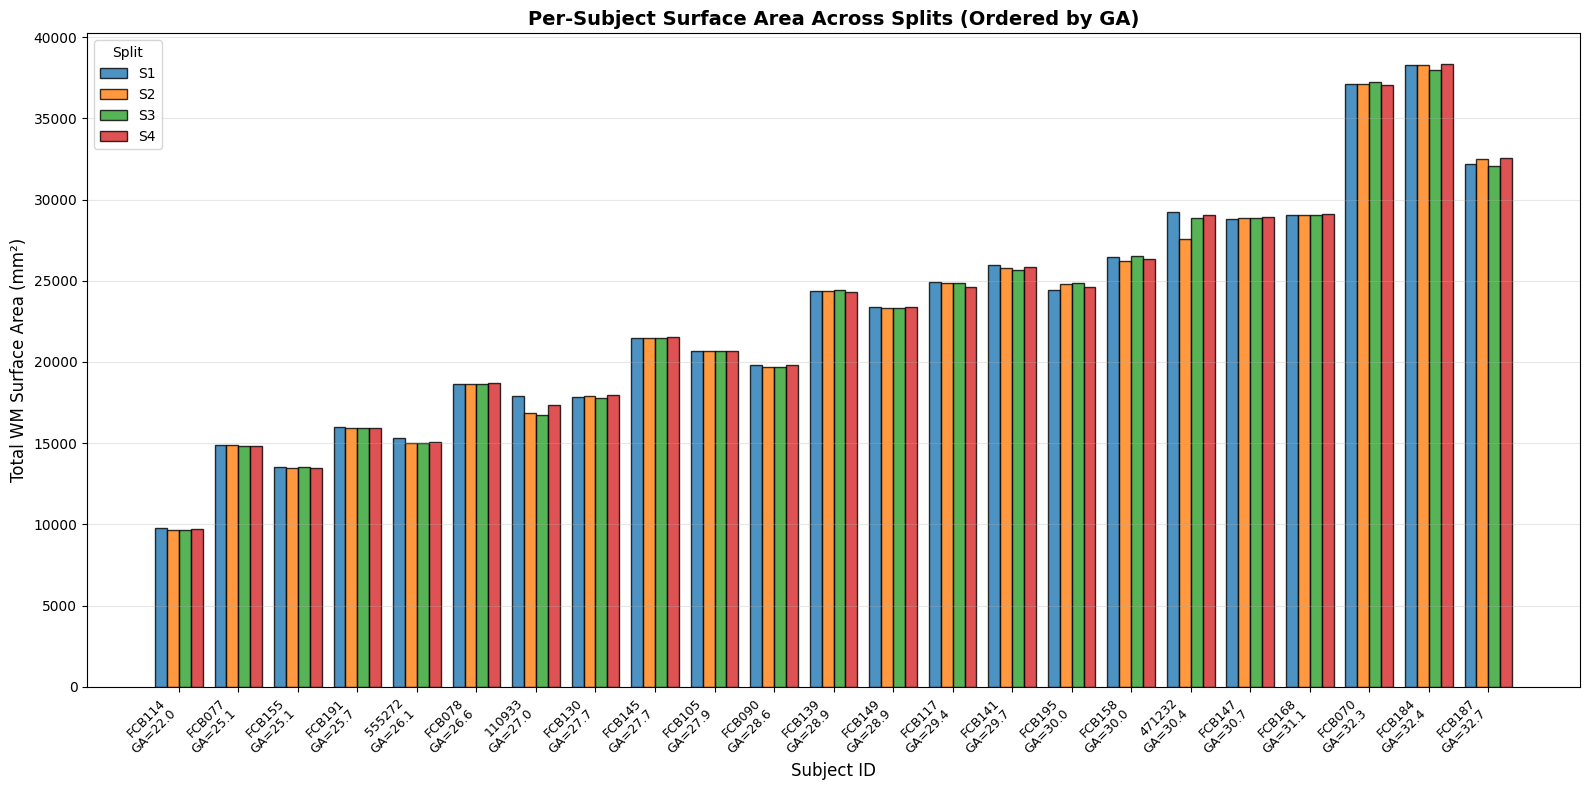

In [20]:
fig, ax = plt.subplots(figsize=(16, 8))

subjects_sorted = subjects_ga.sort_values('GA')
x = np.arange(len(subjects_sorted))
width = 0.2
split_colors = {'S1': '#1f77b4', 'S2': '#ff7f0e', 'S3': '#2ca02c', 'S4': '#d62728'}

for i, split in enumerate(['S1', 'S2', 'S3', 'S4']):
    values = []
    for _, row in subjects_sorted.iterrows():
        subj_id = row['subject_id']
        sess_id = row['session_id']
        data = quality_df[(quality_df['subject_id'] == subj_id) &
                          (quality_df['session_id'] == sess_id) &
                          (quality_df['split'] == split)]['wm_surface_area']
        values.append(data.values[0] if len(data) > 0 else np.nan)

    offset = (i - 1.5) * width
    ax.bar(x + offset, values, width, label=split, color=split_colors[split], alpha=0.8, edgecolor='black')

tick_labels = [f"{str(row['subject_id'])[:6]}\nGA={row['GA']:.1f}" for _, row in subjects_sorted.iterrows()]
ax.set_xticks(x)
ax.set_xticklabels(tick_labels, fontsize=9, rotation=45, ha='right')
ax.set_xlabel('Subject ID', fontsize=12)
ax.set_ylabel('Total WM Surface Area (mm²)', fontsize=12)
ax.set_title('Per-Subject Surface Area Across Splits (Ordered by GA)', fontsize=14, fontweight='bold')
ax.legend(title='Split', loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [7]:
def _compute_split_pair_diff(quality_df, column, split1, split2, relative=True):
    """
    Compute difference between two splits for a given column.
    Uses subject_id + session_id as unique identifier to handle subjects with multiple sessions.
    """
    # Get data for each split
    s1_df = quality_df[quality_df["split"] == split1][
        ["subject_id", "session_id", column]
    ].copy()
    s2_df = quality_df[quality_df["split"] == split2][
        ["subject_id", "session_id", column]
    ].copy()

    # Rename columns for merge
    s1_df = s1_df.rename(columns={column: "val1"})
    s2_df = s2_df.rename(columns={column: "val2"})

    # Merge on subject_id AND session_id to handle subjects with multiple sessions
    result = s1_df.merge(s2_df, on=["subject_id", "session_id"], how="inner")

    # Create a display label (subject_id only, for cleaner plot labels)
    result["label"] = result["subject_id"].astype(str)

    # Compute difference
    if relative:
        mean_val = (result["val1"] + result["val2"]) / 2
        result["diff"] = abs(result["val1"] - result["val2"]) / mean_val * 100
    else:
        result["diff"] = abs(result["val1"] - result["val2"])

    return result


In [ ]:
# SH vs WM surface area
from sklearn.linear_model import RANSACRegressor

# WM surface area absolute differences per split pair
surface_diffs_s1s2 = _compute_split_pair_diff(quality_df, 'wm_surface_area', 'S1', 'S2', relative=False)
surface_diffs_s1s2['split_pair'] = 'S1-S2'
surface_diffs_s3s4 = _compute_split_pair_diff(quality_df, 'wm_surface_area', 'S3', 'S4', relative=False)
surface_diffs_s3s4['split_pair'] = 'S3-S4'
surface_diffs_all = pd.concat([surface_diffs_s1s2, surface_diffs_s3s4], ignore_index=True)

# Surface Homogeneity (SH) absolute differences per split pair.
# Source column is `snr_subplate` for historical reasons; the metric is SH.
sh_diff_s1s2 = _compute_split_pair_diff(quality_df, 'snr_subplate', 'S1', 'S2', relative=False)
sh_diff_s1s2['split_pair'] = 'S1-S2'
sh_diff_s3s4 = _compute_split_pair_diff(quality_df, 'snr_subplate', 'S3', 'S4', relative=False)
sh_diff_s3s4['split_pair'] = 'S3-S4'
sh_all = pd.concat([sh_diff_s1s2, sh_diff_s3s4], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax_idx, pair_name in enumerate(['S1-S2', 'S3-S4']):
    ax = axes[ax_idx]
    ax.tick_params(labelleft=True, labelbottom=True)

    pair_data_surface = surface_diffs_all[surface_diffs_all['split_pair'] == pair_name]
    sh_pair = sh_all[sh_all['split_pair'] == pair_name]

    merged = pair_data_surface.merge(
        sh_pair[['subject_id', 'session_id', 'diff']],
        on=['subject_id', 'session_id'],
        suffixes=('_surface', '_sh'),
    )

    if len(merged) < 3:
        ax.text(0.5, 0.5, f'Insufficient data\n(N={len(merged)})',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(pair_name, fontsize=12, fontweight='bold')
        continue

    x = merged['diff_sh'].values
    y = merged['diff_surface'].values

    ax.scatter(x, y, s=80, alpha=0.7, edgecolors='black', zorder=3)

    r, p = stats.pearsonr(x, y)

    X_reshaped = x.reshape(-1, 1)
    ransac = RANSACRegressor(
        residual_threshold=np.std(y) * 1.5,
        min_samples=0.5,
        random_state=42,
    )
    ransac.fit(X_reshaped, y)

    x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    y_line = ransac.predict(x_line)
    ax.plot(x_line, y_line, 'r--', alpha=0.8, linewidth=2, label='RANSAC fit')

    r2 = ransac.score(X_reshaped, y)

    inlier_mask = ransac.inlier_mask_
    n_inliers = int(np.sum(inlier_mask))
    n_outliers = int(np.sum(~inlier_mask))

    if n_outliers > 0:
        ax.scatter(
            x[~inlier_mask], y[~inlier_mask],
            s=100, facecolors='none', edgecolors='red', linewidths=2, zorder=4,
            label=f'Outliers ({n_outliers})',
        )

    ax.set_xlabel(f'|SH Difference| ({pair_name})', fontsize=11)
    ax.set_ylabel(f'WM Surface Area Abs. Diff (mm²) ({pair_name})', fontsize=11)
    ax.set_title(
        f'{pair_name} | Pearson r={r:.3f}, p={p:.3f} | '
        f'RANSAC R²={r2:.3f} ({n_inliers} inliers, {n_outliers} outliers)',
        fontsize=10, fontweight='bold',
    )
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)

plt.suptitle('SH vs WM Surface Area Reliability', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
from statsmodels.stats.multitest import multipletests

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax_idx, pair_name in enumerate(['S1-S2', 'S3-S4']):
    ax = axes[ax_idx]

    surface_diff = surface_diffs_all[surface_diffs_all['split_pair'] == pair_name].copy()
    sh_diff = sh_all[sh_all['split_pair'] == pair_name].copy()

    surface_diff['subject_id'] = surface_diff['subject_id'].astype(str)
    surface_diff['session_id'] = surface_diff['session_id'].astype(str)
    sh_diff['subject_id'] = sh_diff['subject_id'].astype(str)
    sh_diff['session_id'] = sh_diff['session_id'].astype(str)

    merged = surface_diff[['subject_id', 'session_id', 'diff']].merge(
        sh_diff[['subject_id', 'session_id', 'diff']],
        on=['subject_id', 'session_id'],
        how='inner',
        suffixes=('_surface', '_sh'),
    ).rename(columns={'diff_surface': 'surface_diff', 'diff_sh': 'sh_diff'})

    infodump = infodump_df.copy()
    infodump['subject_id'] = infodump['subject_id'].astype(str)
    infodump['session_id'] = infodump['session_id'].astype(str)

    if pair_name == 'S1-S2':
        if 'QA_S1' in infodump.columns and 'QA_S2' in infodump.columns:
            infodump['qa_diff'] = abs(infodump['QA_S1'] - infodump['QA_S2'])
            infodump['qa_mean'] = (infodump['QA_S1'] + infodump['QA_S2']) / 2
    else:
        if 'QA_S3' in infodump.columns and 'QA_S4' in infodump.columns:
            infodump['qa_diff'] = abs(infodump['QA_S3'] - infodump['QA_S4'])
            infodump['qa_mean'] = (infodump['QA_S3'] + infodump['QA_S4']) / 2

    ga_lookup = infodump[['subject_id', 'session_id', 'GA']].drop_duplicates()
    merged = merged.merge(ga_lookup, on=['subject_id', 'session_id'], how='left')

    merged = merged.merge(
        infodump[['subject_id', 'session_id', 'qa_diff', 'qa_mean']].drop_duplicates(),
        on=['subject_id', 'session_id'],
        how='left',
    )

    corr_data = merged[['surface_diff', 'sh_diff', 'qa_diff', 'qa_mean', 'GA']].dropna()

    if len(corr_data) >= 3:
        corr_matrix = corr_data.corr(method='pearson')
        labels = ['Surf Diff', 'SH Diff', 'QA Diff', 'QA Mean', 'GA']

        im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')

        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, fontsize=9, rotation=45, ha='right')
        ax.set_yticklabels(labels, fontsize=9)

        p_values = []
        p_pairs = []
        for i in range(len(corr_data.columns)):
            for j in range(i + 1, len(corr_data.columns)):
                _, p = stats.pearsonr(corr_data.iloc[:, i], corr_data.iloc[:, j])
                p_values.append(p)
                p_pairs.append((i, j))

        if p_values:
            _, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')
        else:
            p_corrected = []

        p_corrected_dict = {}
        for idx, (i, j) in enumerate(p_pairs):
            p_corrected_dict[(i, j)] = p_corrected[idx] if idx < len(p_corrected) else 1.0
            p_corrected_dict[(j, i)] = p_corrected_dict[(i, j)]

        for i in range(len(labels)):
            for j in range(len(labels)):
                if i == j:
                    mean_val = corr_data.iloc[:, i].mean()
                    std_val = corr_data.iloc[:, i].std()
                    text = f'μ={mean_val:.0f}\nσ={std_val:.0f}'
                    ax.text(j, i, text, ha='center', va='center',
                            color='white', fontsize=8, fontweight='bold')
                else:
                    r = corr_matrix.iloc[i, j]
                    p_val = p_corrected_dict.get((i, j), 1.0)

                    if p_val < 0.001:
                        sig = '***'
                    elif p_val < 0.01:
                        sig = '**'
                    elif p_val < 0.05:
                        sig = '*'
                    else:
                        sig = ''

                    text_color = 'white' if abs(r) > 0.5 else 'black'
                    ax.text(j, i, f'{r:.2f}\n{sig}', ha='center', va='center',
                            color=text_color, fontsize=9, fontweight='bold')

        ax.set_title(f'{pair_name} (N={len(corr_data)})', fontsize=13, fontweight='bold')

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04, shrink=0.8)
cbar.set_label('Pearson r', fontsize=10)

plt.suptitle('Correlation Matrices: Surface Area Differences\n* p<0.05, ** p<0.01, *** p<0.001 (FDR corrected)',
             fontsize=12, fontweight='bold', y=1.00)
fig.subplots_adjust(left=0.08, right=0.85, top=0.92, bottom=0.12, wspace=0.3)
plt.show()
